# Prompt as Navigation: Exploring Diffusion Models Through Iterative Prompting

**Learning objectives**
- Understand how diffusion models generate images from text
- Use the HuggingFace `diffusers` library to run image generation pipelines
- Understand CLIP's shared text–image embedding space
- Experience prompt engineering as *navigation* in a high-dimensional semantic space
- Visualize how different people's prompt trajectories move through that space

**How to use this notebook**  
Run cells top-to-bottom. In Tasks 1 and 2 you will write your own prompts. Copy the template cell, replace `"YourName"` and `"your prompt here"`, run it, observe the image, then iterate. Your history is automatically recorded.

> **Tip:** Keep prompts under ~60 words. CLIP's text encoder silently truncates at 77 tokens.

In [ ]:
%pip install -q diffusers accelerate umap-learn

In [ ]:
import base64
import warnings
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from PIL import Image
from sklearn.decomposition import PCA
from transformers import CLIPModel, CLIPProcessor

warnings.filterwarnings('ignore')
print('Imports OK')

In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
if DEVICE == 'cpu':
    print('  No GPU. Generation will be slow. Consider Colab (Runtime > Change runtime type > T4 GPU).')

---
## 1 · Introduction to HuggingFace Diffusers

### 1.1 How diffusion models work

Diffusion models learn to generate images by reversing a simple corruption process:

1. **Forward process (training):** Take a real image and add Gaussian noise over *T* steps until only noise remains.
2. **Reverse process (inference):** Start from pure noise and iteratively *denoise* (predicting and removing noise at each step) until a clean image emerges.

The denoising network (a U-Net) is conditioned on the text prompt via **cross-attention**: a text encoder (CLIP or T5) converts the prompt into a vector sequence, which attends to the spatial features of the noisy image at every denoising step.

Modern variants reduce the steps needed:
| Variant | Steps | Notes |
|---------|-------|-------|
| DDPM (2020) | ~1000 | Original formulation |
| DDIM (2020) | ~50 | Deterministic sampler |
| LCM / Turbo (2023–24) | 1–8 | Distilled; very fast |

### 1.2 The `diffusers` pipeline abstraction

`diffusers` wraps tokenization, encoding, denoising, and decoding into a single object:

```python
from diffusers import AutoPipelineForText2Image
pipe = AutoPipelineForText2Image.from_pretrained('stabilityai/sdxl-turbo')
image = pipe('a red apple on a wooden table', num_inference_steps=4, guidance_scale=0.0).images[0]
```

Key parameters:
- `num_inference_steps` — denoising steps (more = slower, often higher quality)
- `guidance_scale` — how strongly the prompt steers the result. **SDXL-Turbo requires `0.0`** (it was distilled to run without classifier-free guidance).
- `generator` — seeded `torch.Generator` for reproducibility

In [ ]:
from diffusers import AutoPipelineForText2Image, StableDiffusionPipeline

pipe = AutoPipelineForText2Image.from_pretrained(
    'stabilityai/sdxl-turbo',
    torch_dtype=torch.float16,
    variant='fp16',
).to(DEVICE)
STEPS, GUIDANCE = 4, 0.0
print('Loaded SDXL-Turbo (GPU)')
# pipe = StableDiffusionPipeline.from_pretrained(
#     'runwayml/stable-diffusion-v1-5',
#     torch_dtype=torch.float32,
#     safety_checker=None,
# ).to(DEVICE)
# pipe.enable_attention_slicing()
# STEPS, GUIDANCE = 20, 7.5
# print('Loaded SD v1.5 (CPU — expect ~3–5 min per image)')

  0%|          | 0/4 [00:00<?, ?it/s]

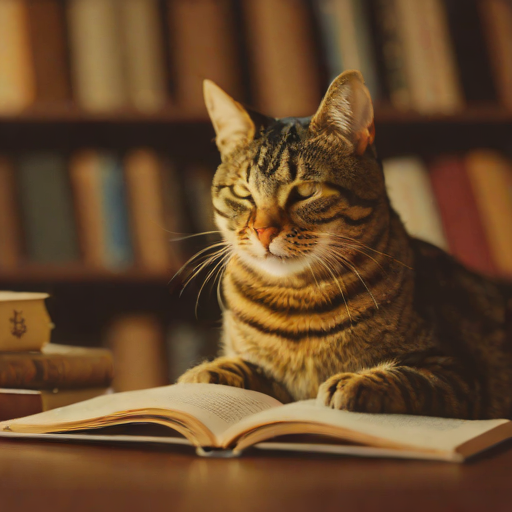

In [69]:
def generate_image(prompt: str, seed: int = 7) -> Image.Image:
    """Generate a 512×512 image from a text prompt."""
    g = torch.Generator(device=DEVICE).manual_seed(seed)
    return pipe(
        prompt=prompt,
        num_inference_steps=STEPS,
        guidance_scale=GUIDANCE,
        height=512,
        width=512,
        generator=g,
    ).images[0]


demo_img = generate_image('a tabby cat reading a book in a cozy library, warm light')
display(demo_img)

> **Discussion:** What do you notice? Is the prompt faithfully represented? What details did the model get right or wrong? Try changing a single word and re-running. What happens if you remove `tabby` from the prompt or add a typo to a crucial word?

---
## 2 · CLIP: A Shared Text–Image Embedding Space

**CLIP** (Contrastive Language–Image Pre-training, OpenAI 2021) was trained on 400 million (image, caption) pairs with a contrastive objective: matching pairs are pushed *together* in a shared embedding space; non-matching pairs are pushed *apart*.

The result is a **512-dimensional space** where:
- A photo of a lighthouse and the text *'a lighthouse on a cliff'* land close together
- Unrelated texts and images land far apart

This is exactly what we need: we can measure how well any prompt matches any image, and track how prompt iterations move through that space relative to a reference target.

In [ ]:
clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
clip_proc  = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
clip_model.eval()
print('CLIP loaded')

In [ ]:
def embed_text(text: str) -> np.ndarray:
    """Return a unit-norm CLIP text embedding (512-d)."""
    inp = clip_proc(text=[text], return_tensors='pt', padding=True, truncation=True)
    with torch.no_grad():
        # pooler_output: (1, hidden_dim=512) — the [CLS] token after pooling
        f = clip_model.text_projection(clip_model.text_model(**inp).pooler_output)
    f = f / f.norm(dim=-1, keepdim=True)
    return f.squeeze().cpu().numpy()


def embed_image(img: Image.Image) -> np.ndarray:
    """Return a unit-norm CLIP image embedding (512-d)."""
    inp = clip_proc(images=img, return_tensors='pt')
    with torch.no_grad():
        # pooler_output: (1, hidden_dim=768) — the [CLS] patch after pooling
        f = clip_model.visual_projection(clip_model.vision_model(**inp).pooler_output)
    f = f / f.norm(dim=-1, keepdim=True)
    return f.squeeze().cpu().numpy()


def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine similarity between two unit-norm vectors."""
    return float(np.dot(a, b))


# Mini demo: which text description is closest to the generated cat image?
candidates = [
    'a cat sitting in a library',
    'a dog running in a park',
    'a lighthouse on a rocky coast',
]
img_vec = embed_image(demo_img)
print('Cosine similarity (demo cat image vs. each text):')
for t in candidates:
    print(f'  {cosine_sim(embed_text(t), img_vec):.4f}  |  {t}')

---
## 3 · Task 1 — Replicate a Reference Image

A reference image has been generated from a **hidden prompt** (revealed at the end of this section). Your goal is to write a sequence of prompts that produces an image as similar to it as possible.

**Rules:**
1. Study the reference image below.
2. Write a first-attempt prompt in the template cell. Run it.
3. Compare your image to the reference. Adjust and run again.
4. Repeat at least 3 times. Then run the analysis cells to see your trajectory.

The cell prints a live cosine-similarity score after each step so you can track numerical progress alongside the visual.

  0%|          | 0/4 [00:00<?, ?it/s]

Reference image (Task 1):


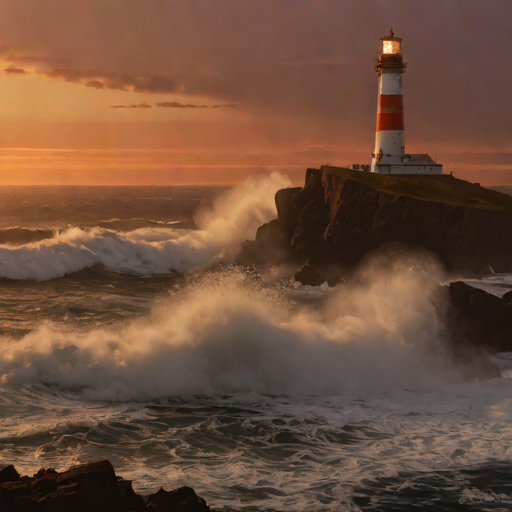

In [70]:
# The reference image is generated from a base64-obfuscated prompt so you can't
# accidentally read it. Do NOT reveal the prompt.
HIDDEN_PROMPT_B64 = (
    'YSBsb25lIGxpZ2h0aG91c2Ugb24gYSByb2NreSBjbGlmZiBhdCBkdXNrLCBkcmFtYXRp'
    'YyBvcmFuZ2Ugc2t5LCBvY2VhbiB3YXZlcyBjcmFzaGluZyBiZWxvdywgcGhvdG9yZWFs'
    'aXN0aWM='
)
# Use the same seed for the reference image as the default participant seed (42)
# so that entering the exact hidden prompt generates an identical image.
REFERENCE_SEED = 7
_hidden = base64.b64decode(HIDDEN_PROMPT_B64).decode()

ref_image = generate_image(_hidden, seed=REFERENCE_SEED)
print('Reference image (Task 1):')
display(ref_image)

In [ ]:
task1_history: dict = defaultdict(list)


def record(history: dict, participant: str, prompt: str, img: Image.Image) -> None:
    """Record a prompt+image step and print text-to-text similarity to the hidden target."""
    history[participant].append({'prompt': prompt, 'image': img})
    step = len(history[participant])
    # Compare against the TARGET TEXT so similarity = 1.0 for the exact hidden prompt
    sim = cosine_sim(embed_text(prompt), embed_text(_hidden))
    print(f'[{participant}] Step {step} — similarity to target prompt: {sim:.4f}')


def display_history(history: dict) -> None:
    """Show every participant's image progression as a row of thumbnails."""
    for name, steps in history.items():
        if not steps:
            continue
        n = len(steps)
        fig, axes = plt.subplots(1, n, figsize=(4 * n, 4.5))
        if n == 1:
            axes = [axes]
        fig.suptitle(name, fontsize=13, fontweight='bold')
        for ax, step in zip(axes, steps):
            if step['image'] is not None:
                ax.imshow(step['image'])
            lbl = step['prompt']
            if len(lbl) > 48:
                lbl = lbl[:45] + '...'
            ax.set_title(lbl, fontsize=7)
            ax.axis('off')
        plt.tight_layout()
        plt.show()

### Your turn

**Copy the template cell below** for each iteration. Change `"YourName"` and `"your prompt here"`, then run the cell.

In [ ]:
# COPY THIS CELL FOR EACH ITERATION (Task 1)
prompt = 'your prompt here'
img    = generate_image(prompt)
record(task1_history, 'YourName', prompt, img)
display(img)

In [ ]:
display_history(task1_history)

---
## 4 · Task 2 — Depict an Abstract Concept

This time there is **no reference image**. The target is the abstract concept:

## `"The feeling of being watched by something you cannot see."`

Generate an image that you feel best depicts *the feeling of being watched by something you cannot see*.

There is no single correct answer. The anchor in CLIP space is the text embedding of the description `"The feeling of being watched by something you cannot see"`. After everyone is done, we will see whether participants converged on similar visual metaphors or diverged across the space.

**Same rules as Task 1:** write at least 3 iterative prompts using the template cell below.

In [ ]:
CONCEPT = 'The feeling of being watched by something you cannot see'
task2_history: dict = defaultdict(list)
_concept_vec = embed_text(CONCEPT)  # pre-compute once


def record2(history: dict, participant: str, prompt: str, img: Image.Image) -> None:
    """Record a prompt+image step and print text–text similarity to the concept."""
    history[participant].append({'prompt': prompt, 'image': img})
    step = len(history[participant])
    sim  = cosine_sim(embed_text(prompt), _concept_vec)
    print(f'[{participant}] Step {step} — text similarity to "{CONCEPT}": {sim:.4f}')

In [ ]:
# ---- COPY THIS CELL FOR EACH ITERATION (Task 2) ----
prompt = 'your prompt here'
img    = generate_image(prompt)
record2(task2_history, 'YourName', prompt, img)
display(img)

In [ ]:
display_history(task2_history)